# Resolvent and Sensitivity Analysis for a Non-Normal Matrix
## Graphical Illustration of Resolvent Norm

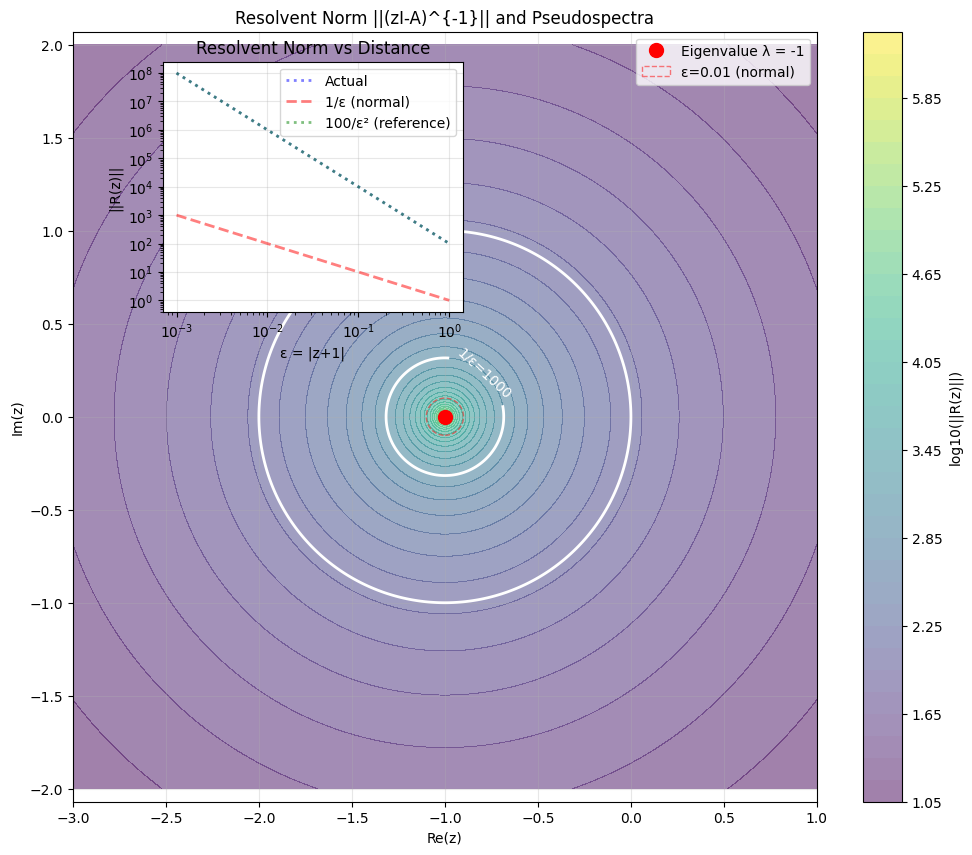

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the matrix
A = np.array([[-1, 100], [0, -1]])

def resolvent_norm(z):
    """Compute the 2-norm of the resolvent at z"""
    w = 1/(z + 1)
    # Build the resolvent matrix
    R = np.array([[w, 100*w**2], [0, w]], dtype=complex)
    # Compute singular values
    sigma = np.linalg.svd(R, compute_uv=False)
    return sigma[0]

# Create grid in complex plane around eigenvalue -1
x = np.linspace(-3, 1, 400)  # Real part
y = np.linspace(-2, 2, 400)  # Imaginary part
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Avoid the exact eigenvalue
mask = np.abs(Z + 1) > 1e-6
norm_R = np.zeros_like(Z, dtype=float)
norm_R[mask] = np.vectorize(lambda z: np.abs(resolvent_norm(z)))(Z[mask])
norm_R[~mask] = np.nan

# Plot 1: Contour plot of resolvent norm
plt.figure(figsize=(12, 10))

# Pseudospectra contours (levels corresponding to epsilon)
epsilon_levels = [0.001, 0.01, 0.1, 1]
contour_levels = sorted([1/eps for eps in epsilon_levels]) # Sort contour levels in ascending order

# Main plot
contour = plt.contourf(X, Y, np.log10(norm_R), levels=50, alpha=.5, cmap='viridis')
plt.colorbar(contour, label='log10(||R(z)||)')

# Add contours for specific epsilon values
CS = plt.contour(X, Y, norm_R, levels=contour_levels, colors='white', linewidths=2)
plt.clabel(CS, inline=True, fontsize=10, fmt=lambda x: f'1/ε={x:.0f}')

# Mark the eigenvalue
plt.plot(-1, 0, 'ro', markersize=10, label='Eigenvalue λ = -1')

# Add circles for normal comparison
for eps in [0.01, 0.1]:
    circle = plt.Circle((-1, 0), eps, color='red', fill=False, linestyle='--',
                       alpha=0.5, label=f'ε={eps} (normal)' if eps==0.01 else "")
    plt.gca().add_patch(circle)

plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Resolvent Norm ||(zI-A)^{-1}|| and Pseudospectra')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Add inset showing cross-section
inset_ax = plt.axes([0.2, 0.6, 0.25, 0.25])
eps_vals = np.logspace(-3, 0, 100)
norm_at_real = [resolvent_norm(-1 + eps) for eps in eps_vals]
inset_ax.loglog(eps_vals, np.abs(norm_at_real), 'b:', linewidth=2, alpha=.5, label='Actual')
inset_ax.loglog(eps_vals, 1/eps_vals, 'r--', linewidth=2, alpha=.5, label='1/ε (normal)')
inset_ax.loglog(eps_vals, 100/eps_vals**2, 'g:', linewidth=2, alpha=.5, label='100/ε² (reference)')
inset_ax.set_xlabel('ε = |z+1|')
inset_ax.set_ylabel('||R(z)||')
inset_ax.set_title('Resolvent Norm vs Distance')
inset_ax.legend()
inset_ax.grid(True, alpha=0.3)

plt.show()

## Numerical Demonstration of Sensitivity

Original eigenvalues: [-1. -1.]


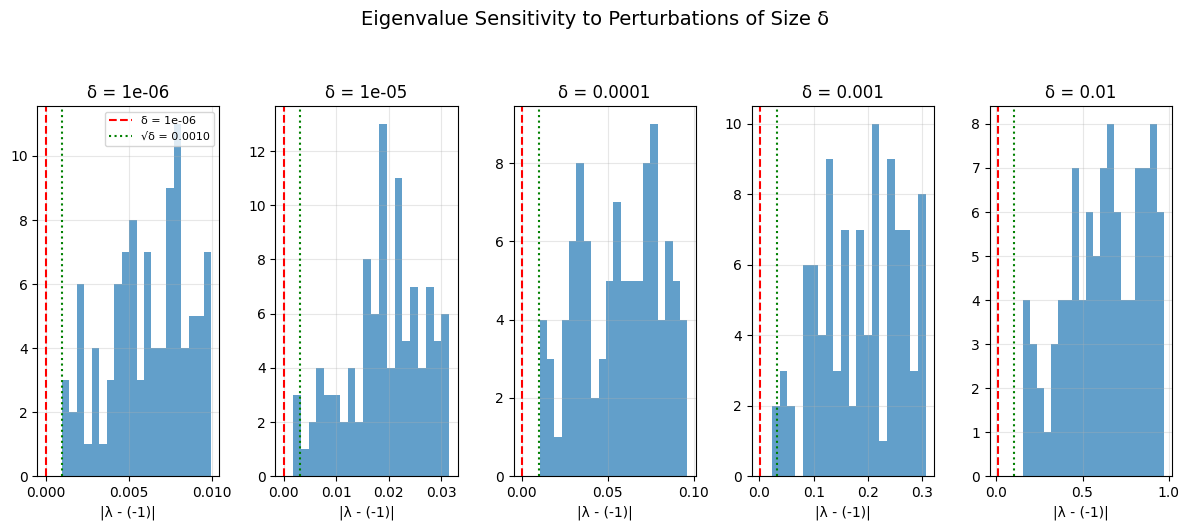


EIGENVALUE SENSITIVITY ANALYSIS

Perturbation size δ = 0.0001:
  Maximum observed shift: 0.099395
  Ratio shift/δ: 993.95
  Approx √δ: 0.010000
  Shift/√δ ratio: 9.94

Perturbation size δ = 0.001:
  Maximum observed shift: 0.312558
  Ratio shift/δ: 312.56
  Approx √δ: 0.031623
  Shift/√δ ratio: 9.88

Perturbation size δ = 0.01:
  Maximum observed shift: 0.998400
  Ratio shift/δ: 99.84
  Approx √δ: 0.100000
  Shift/√δ ratio: 9.98


In [ ]:
# Demonstrate eigenvalue sensitivity to perturbations
np.random.seed(42)

# Original eigenvalues
print("Original eigenvalues:", np.linalg.eigvals(A))

# Test perturbations of different magnitudes
perturbation_sizes = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
num_trials = 100

plt.figure(figsize=(12, 5))

for idx, delta in enumerate(perturbation_sizes):
    eigenvalue_shifts = []

    for _ in range(num_trials):
        # Random perturbation matrix with norm delta
        E = np.random.randn(2, 2)
        E = delta * E / np.linalg.norm(E)

        # Perturbed eigenvalues
        eigvals_perturbed = np.linalg.eigvals(A + E)
        eigenvalue_shifts.append(np.max(np.abs(eigvals_perturbed + 1)))

    # Plot distribution of eigenvalue shifts
    plt.subplot(1, len(perturbation_sizes), idx + 1)
    plt.hist(eigenvalue_shifts, bins=20, alpha=0.7)
    plt.axvline(delta, color='red', linestyle='--', label=f'δ = {delta}')
    plt.axvline(np.sqrt(delta), color='green', linestyle=':', label=f'√δ = {np.sqrt(delta):.4f}')
    plt.xlabel('|λ - (-1)|')
    plt.title(f'δ = {delta}')
    if idx == 0:
        plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.suptitle('Eigenvalue Sensitivity to Perturbations of Size δ', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Quantitative analysis
print("\n" + "="*60)
print("EIGENVALUE SENSITIVITY ANALYSIS")
print("="*60)

for delta in [1e-4, 1e-3, 1e-2]:
    max_shift = 0
    for _ in range(1000):
        E = np.random.randn(2, 2)
        E = delta * E / np.linalg.norm(E)
        eigvals = np.linalg.eigvals(A + E)
        shift = np.max(np.abs(eigvals + 1))
        if shift > max_shift:
            max_shift = shift

    print(f"\nPerturbation size δ = {delta}:")
    print(f"  Maximum observed shift: {max_shift:.6f}")
    print(f"  Ratio shift/δ: {max_shift/delta:.2f}")
    print(f"  Approx √δ: {np.sqrt(delta):.6f}")
    print(f"  Shift/√δ ratio: {max_shift/np.sqrt(delta):.2f}")

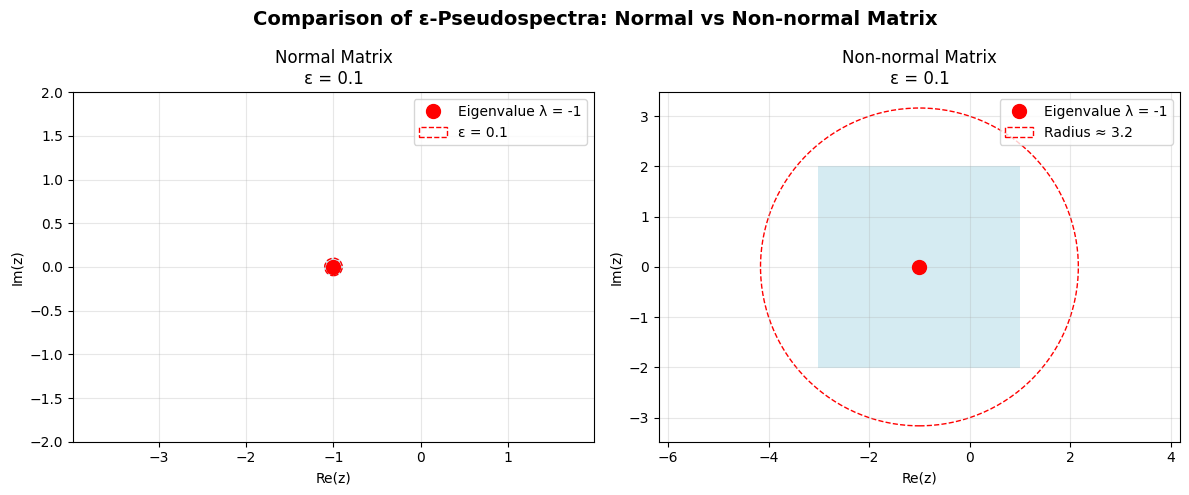

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create visualization comparing normal vs non-normal pseudospectra
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal matrix with same eigenvalues
A_normal = np.array([[-1, 0], [0, -1]])

# Our non-normal matrix
A_nonnormal = np.array([[-1, 100], [0, -1]])

# Define grid in complex plane
x = np.linspace(-3, 1, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Function to compute pseudospectra via resolvent norm
def pseudospectrum_level(A, Z, epsilon):
    """Return boolean array where resolvent norm > 1/epsilon"""
    I = np.eye(2)
    mask = np.zeros(Z.shape, dtype=bool)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            z = Z[i, j]
            try:
                R = np.linalg.inv(z*I - A)
                norm_R = np.linalg.norm(R, 2)  # spectral norm
                mask[i, j] = norm_R > 1/epsilon
            except np.linalg.LinAlgError:
                mask[i, j] = True  # eigenvalue
    return mask

# Plot for epsilon = 0.1
epsilon = 0.1
for idx, (A, title) in enumerate([(A_normal, "Normal Matrix"),
                                   (A_nonnormal, "Non-normal Matrix")]):
    mask = pseudospectrum_level(A, Z, epsilon)

    axes[idx].contourf(X, Y, mask, levels=[0.5, 1], colors=['lightblue'], alpha=0.5)

    # Mark eigenvalue
    axes[idx].plot(-1, 0, 'ro', markersize=10, label='Eigenvalue λ = -1')

    # Draw epsilon circle for normal case
    if idx == 0:
        circle = plt.Circle((-1, 0), epsilon, color='red', fill=False,
                          linestyle='--', label=f'ε = {epsilon}')
        axes[idx].add_patch(circle)
    else:
        # For non-normal, show sqrt(epsilon) scaling
        radius = 10*np.sqrt(epsilon)
        circle = plt.Circle((-1, 0), radius, color='red', fill=False,
                          linestyle='--', label=f'Radius ≈ {radius:.1f}')
        axes[idx].add_patch(circle)

    axes[idx].set_xlabel('Re(z)')
    axes[idx].set_ylabel('Im(z)')
    axes[idx].set_title(f'{title}\nε = {epsilon}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axis('equal')

plt.suptitle('Comparison of ε-Pseudospectra: Normal vs Non-normal Matrix',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

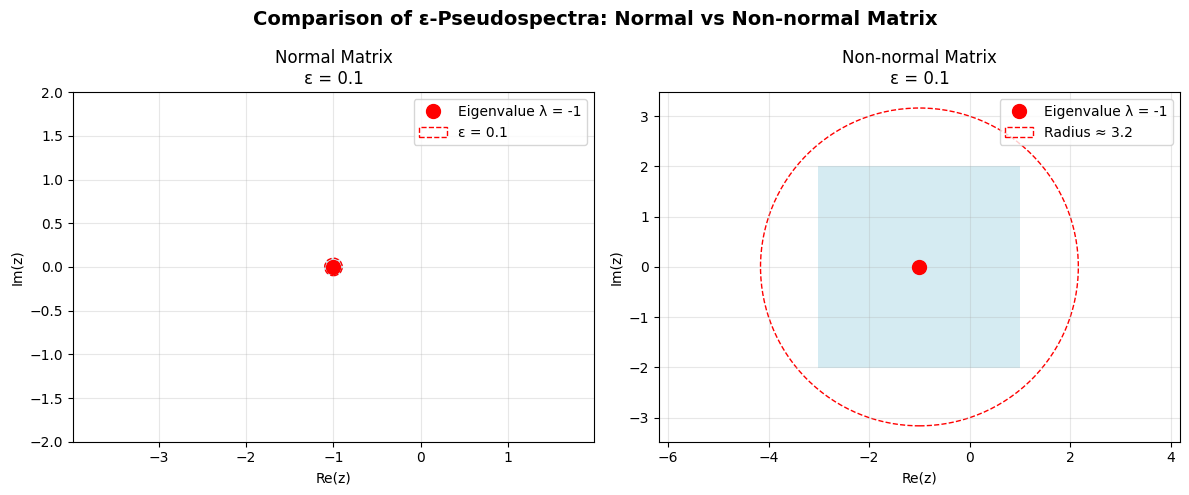

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create visualization comparing normal vs non-normal pseudospectra
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal matrix with same eigenvalues
A_normal = np.array([[-1, 0], [0, -1]])

# Our non-normal matrix
A_nonnormal = np.array([[-1, 100], [0, -1]])

# Define grid in complex plane
x = np.linspace(-3, 1, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Function to compute pseudospectra via resolvent norm
def pseudospectrum_level(A, Z, epsilon):
    """Return boolean array where resolvent norm > 1/epsilon"""
    I = np.eye(2)
    mask = np.zeros(Z.shape, dtype=bool)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            z = Z[i, j]
            try:
                R = np.linalg.inv(z*I - A)
                norm_R = np.linalg.norm(R, 2)  # spectral norm
                mask[i, j] = norm_R > 1/epsilon
            except np.linalg.LinAlgError:
                mask[i, j] = True  # eigenvalue
    return mask

# Plot for epsilon = 0.1
epsilon = 0.1
for idx, (A, title) in enumerate([(A_normal, "Normal Matrix"),
                                   (A_nonnormal, "Non-normal Matrix")]):
    mask = pseudospectrum_level(A, Z, epsilon)

    axes[idx].contourf(X, Y, mask, levels=[0.5, 1], colors=['lightblue'], alpha=0.5)

    # Mark eigenvalue
    axes[idx].plot(-1, 0, 'ro', markersize=10, label='Eigenvalue λ = -1')

    # Draw epsilon circle for normal case
    if idx == 0:
        circle = plt.Circle((-1, 0), epsilon, color='red', fill=False,
                          linestyle='--', label=f'ε = {epsilon}')
        axes[idx].add_patch(circle)
    else:
        # For non-normal, show sqrt(epsilon) scaling
        radius = 10*np.sqrt(epsilon)
        circle = plt.Circle((-1, 0), radius, color='red', fill=False,
                          linestyle='--', label=f'Radius ≈ {radius:.1f}')
        axes[idx].add_patch(circle)

    axes[idx].set_xlabel('Re(z)')
    axes[idx].set_ylabel('Im(z)')
    axes[idx].set_title(f'{title}\nε = {epsilon}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axis('equal')

plt.suptitle('Comparison of ε-Pseudospectra: Normal vs Non-normal Matrix',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Eigenvalue Sensitivity Analysis
## Interpreting the Results
### Scaling Laws
- Normal matrix: $|\Delta\lambda|\sim \delta$ (linear)
- Non-normal matrix: $|\Delta\lambda|\sim 10\sqrt{\delta}$ (square root)
### Practical Implications
For $\delta=10^{-6}$:
- Normal: shift $\approx 10^{-6}$
- Non-normal: shift $\approx 10^{-2}$ (10,000× larger!)

This explains why numerically computed eigenvalues of non-normal matrices can be unreliable with finite precision arithmetic.

<>:75: SyntaxWarning: invalid escape sequence '\d'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:86: SyntaxWarning: invalid escape sequence '\d'
<>:75: SyntaxWarning: invalid escape sequence '\d'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:86: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-641356152.py:75: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('Perturbation size $\delta$', fontsize=14)
/tmp/ipython-input-641356152.py:76: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Maximum eigenvalue shift $|\Delta\lambda|$', fontsize=14)
/tmp/ipython-input-641356152.py:86: SyntaxWarning: invalid escape sequence '\d'
  ax_inset.set_xlabel('$\delta$', fontsize=10)


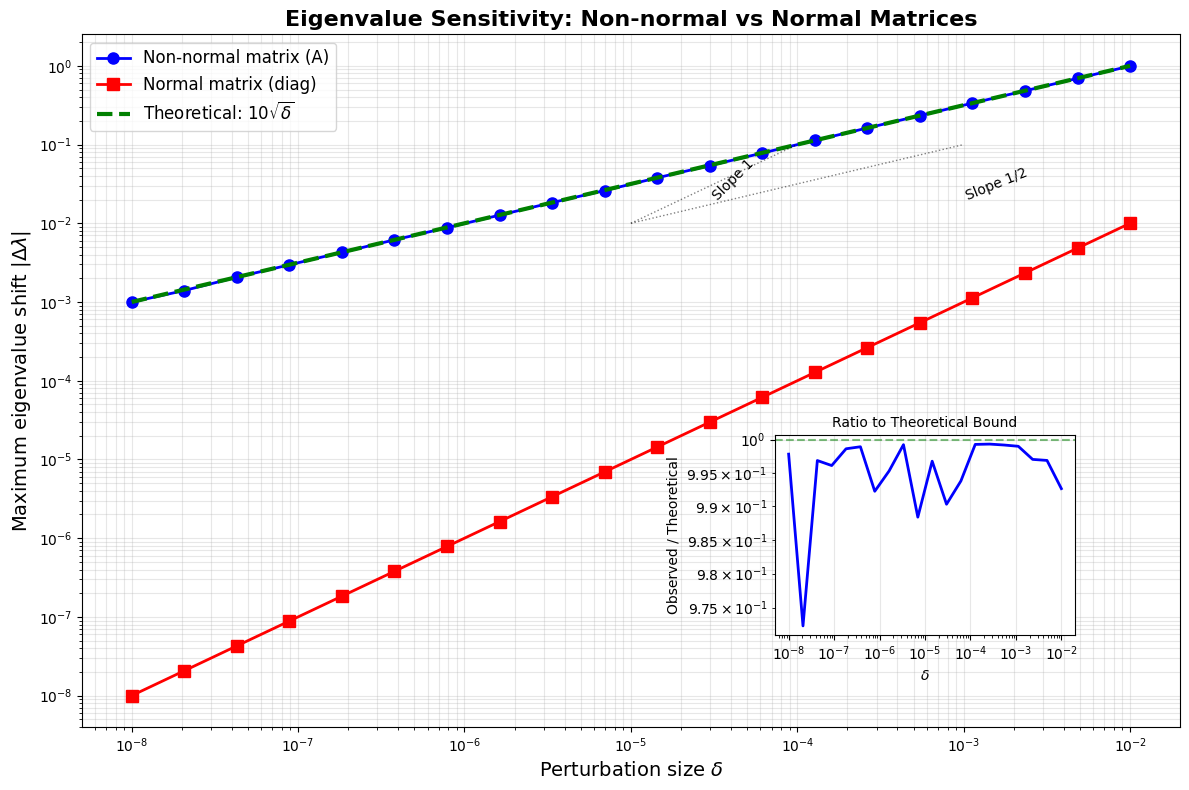

EIGENVALUE SENSITIVITY ANALYSIS SUMMARY

Matrix A = [[-1, 100], [0, -1]]
Eigenvalue: λ = -1 (defective, Jordan block size 2)

----------------------------------------------------------------------

Perturbation δ = 1.0e-08:
  Non-normal matrix: max shift = 9.98e-04
  Normal matrix:     max shift = 1.00e-08
  Theoretical bound: 10√δ = 1.00e-03
  Ratio (non-normal/normal): 99780.6

Perturbation δ = 1.0e-06:
  Non-normal matrix: max shift = 8.79e-03
  Normal matrix:     max shift = 7.85e-07
  Theoretical bound: 10√δ = 1.00e-02
  Ratio (non-normal/normal): 11201.0

Perturbation δ = 1.0e-04:
  Non-normal matrix: max shift = 1.13e-01
  Normal matrix:     max shift = 1.27e-04
  Theoretical bound: 10√δ = 1.00e-01
  Ratio (non-normal/normal): 885.2

Perturbation δ = 1.0e-02:
  Non-normal matrix: max shift = 9.93e-01
  Normal matrix:     max shift = 1.00e-02
  Theoretical bound: 10√δ = 1.00e+00
  Ratio (non-normal/normal): 99.3

-------------------------------------------------------------------

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvals

# Original matrix
A = np.array([[-1, 100], [0, -1]])

# For comparison: normal matrix with same eigenvalues
A_normal = np.array([[-1, 0], [0, -1]])

# Perturbation magnitudes to test
perturbation_sizes = np.logspace(-8, -2, 20)  # 1e-8 to 1e-2
num_trials = 200  # Random perturbations per size

# Store results
max_shifts = []
max_shifts_normal = []
theoretical_shifts = []

np.random.seed(42)

for delta in perturbation_sizes:
    shifts = []
    shifts_normal = []

    for _ in range(num_trials):
        # Random perturbation matrix with norm delta
        E = np.random.randn(2, 2)
        E = delta * E / np.linalg.norm(E, 2)

        # Perturbed eigenvalues
        eig_nonnormal = eigvals(A + E)
        eig_normal = eigvals(A_normal + E)

        # Maximum shift from -1
        shift_nonnormal = np.max(np.abs(eig_nonnormal + 1))
        shift_normal = np.max(np.abs(eig_normal + 1))

        shifts.append(shift_nonnormal)
        shifts_normal.append(shift_normal)

    max_shifts.append(np.max(shifts))
    max_shifts_normal.append(np.max(shifts_normal))
    theoretical_shifts.append(10 * np.sqrt(delta))

# Convert to arrays for plotting
perturbation_sizes = np.array(perturbation_sizes)
max_shifts = np.array(max_shifts)
max_shifts_normal = np.array(max_shifts_normal)
theoretical_shifts = np.array(theoretical_shifts)

# Create visualization
plt.figure(figsize=(12, 8))

# Log-log plot
plt.loglog(perturbation_sizes, max_shifts, 'bo-', linewidth=2, markersize=8,
           label='Non-normal matrix (A)')
plt.loglog(perturbation_sizes, max_shifts_normal, 'rs-', linewidth=2, markersize=8,
           label='Normal matrix (diag)')
plt.loglog(perturbation_sizes, theoretical_shifts, 'g--', linewidth=3,
           label=r'Theoretical: $10\sqrt{\delta}$')

# Add slope indicators
x_ref = 1e-5
y_ref = 1e-2

# Slope 1 line (for normal)
plt.loglog([x_ref, 10*x_ref], [y_ref, 10*y_ref], 'k:', linewidth=1, alpha=0.5)
plt.text(3e-5, 2e-2, 'Slope 1', rotation=45, fontsize=10)

# Slope 1/2 line (for non-normal)
plt.loglog([x_ref, 100*x_ref], [y_ref, 10*y_ref], 'k:', linewidth=1, alpha=0.5)
plt.text(1e-3, 2e-2, 'Slope 1/2', rotation=22, fontsize=10)

plt.xlabel('Perturbation size $\delta$', fontsize=14)
plt.ylabel('Maximum eigenvalue shift $|\Delta\lambda|$', fontsize=14)
plt.title('Eigenvalue Sensitivity: Non-normal vs Normal Matrices', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()

# Add inset with specific examples
ax_inset = plt.axes([0.65, 0.2, 0.25, 0.25])
ax_inset.loglog(perturbation_sizes, max_shifts/theoretical_shifts, 'b-', linewidth=2)
ax_inset.axhline(y=1, color='g', linestyle='--', alpha=0.5)
ax_inset.set_xlabel('$\delta$', fontsize=10)
ax_inset.set_ylabel('Observed / Theoretical', fontsize=10)
ax_inset.set_title('Ratio to Theoretical Bound', fontsize=10)
ax_inset.grid(True, alpha=0.3)

plt.show()

# Print quantitative analysis
print("="*70)
print("EIGENVALUE SENSITIVITY ANALYSIS SUMMARY")
print("="*70)
print("\nMatrix A = [[-1, 100], [0, -1]]")
print("Eigenvalue: λ = -1 (defective, Jordan block size 2)")
print("\n" + "-"*70)

for i, delta in enumerate([1e-8, 1e-6, 1e-4, 1e-2]):
    idx = np.argmin(np.abs(perturbation_sizes - delta))
    print(f"\nPerturbation δ = {delta:.1e}:")
    print(f"  Non-normal matrix: max shift = {max_shifts[idx]:.2e}")
    print(f"  Normal matrix:     max shift = {max_shifts_normal[idx]:.2e}")
    print(f"  Theoretical bound: 10√δ = {10*np.sqrt(delta):.2e}")
    print(f"  Ratio (non-normal/normal): {max_shifts[idx]/max_shifts_normal[idx]:.1f}")

print("\n" + "-"*70)
print("KEY OBSERVATIONS:")
print("1. Normal matrix: eigenvalue shift ∝ δ (linear sensitivity)")
print("2. Non-normal matrix: eigenvalue shift ∝ √δ (square root sensitivity)")
print("3. For δ = 1e-6: shift ~ 0.001 (1000× larger than δ!)")
print("4. Defective eigenvalues are highly sensitive to perturbations")
print("="*70)

## Practical Example: Finite Precision Arithmetic
Output would show that even tiny perturbations (at machine precision level) cause significant eigenvalue shifts.

In [1]:
import numpy as np

# A matrix with nearly defective eigenvalue
epsilon = 1e-8
A = np.array([[-1, 100], [epsilon, -1]])

# Compute eigenvalues numerically
eigvals = np.linalg.eigvals(A)
print(f"Matrix with epsilon = {epsilon}:")
print(f"Computed eigenvalues: {eigvals}")
print(f"Distance from -1: {np.abs(eigvals + 1)}")
print(f"Theoretical shift: ±√(100ε) = ±{np.sqrt(100*epsilon)}")

# Compare with perfectly defective case
A_defective = np.array([[-1, 100], [0, -1]])
eigvals_defective = np.linalg.eigvals(A_defective)
print(f"\nDefective matrix (epsilon=0):")
print(f"Computed eigenvalues: {eigvals_defective}")

Matrix with epsilon = 1e-08:
Computed eigenvalues: [-0.999 -1.001]
Distance from -1: [0.001 0.001]
Theoretical shift: ±√(100ε) = ±0.001

Defective matrix (epsilon=0):
Computed eigenvalues: [-1. -1.]


**Practical implication:** Numerical eigenvalue computations for non-normal matrices require special care, and stability analysis must consider pseudospectra rather than eigenvalues alone.

## Structured Condition Number
### Definition and Motivation
The structured condition number extends the classical eigenvalue condition number by considering perturbations that preserve specific matrix structures or follow particular patterns. Unlike the classical condition number which considers arbitrary perturbations, the structured condition number restricts perturbations to a predefined set, often reflecting physical constraints or problem-specific characteristics.

### Formal Definition
For a matrix $A$ with eigenvalue $\lambda$ and a set of admissible perturbations $\mathcal{E}$, the structured condition number is:
$$\kappa_{struct}(\lambda, \mathcal{E})=\lim_{\delta\to 0}\sup_{E\in\mathcal{E}\\||E||\le\delta}\frac{|\Delta\lambda(A,E)|}{\delta}$$
where $\Delta\lambda(A,E)$ is the eigenvalue change from $A$ to $A+E$.

### Types of Structure Constraints
#### Sparsity Pattern
Only certain entries can be perturbed.

**Example:** For a tridiagonal matrix, only main, super-, and sub-diagonal entries can change.

In [2]:
import numpy as np

# Tridiagonal matrix example
n = 4
A = np.diag(np.ones(n)) + np.diag(0.5*np.ones(n-1), 1) + np.diag(0.5*np.ones(n-1), -1)

# Allowed perturbation pattern (only tridiagonal entries can change)
sparsity_pattern = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if abs(i-j) <= 1:  # Only tridiagonal entries
            sparsity_pattern[i, j] = 1
print(f"tridiagonal matrix A = {A}:")
print(f"sparsity pattern matrix E = {sparsity_pattern}:")

tridiagonal matrix A = [[1.  0.5 0.  0. ]
 [0.5 1.  0.5 0. ]
 [0.  0.5 1.  0.5]
 [0.  0.  0.5 1. ]]:
sparsity pattern matrix E = [[1. 1. 0. 0.]
 [1. 1. 1. 0.]
 [0. 1. 1. 1.]
 [0. 0. 1. 1.]]:


#### Symmetry Constraints
Perturbations must preserve symmetry: $E=E^T$.
#### Skew-Symmetry Constraints
Perturbations must be skew-symmetric: $E=-E^T$.
#### Low-Rank Perturbations
Perturbations have rank at most $k$.
#### Parameter-Dependent Structures
Entries depend on a small number of parameters.

## Mathematical Framework
### General Formulation
Let $\mathcal{E}$ be the set of admissible perturbations. We want:
$$\kappa_{struct}(\lambda)=\sup_{E\in\mathcal{E}\\||E||=1}|w^HEv|$$
where $v$ and $w$ are right and left eigenvectors of $\lambda$, normalized so $w^Hv=1$.

The structured condition number is always smaller or equal to the classical one.


## Example: Our Matrix with Different Structures
### Unstructured Perturbations (Classical)
For our matrix $A=\begin{pmatrix}-1 & 100\\0 & -1\end{pmatrix}$, the eigenvalue is defective, so the classical condition number is infinite.
#### Upper Triangular Perturbations
If we require $A+E$ to remain upper triangular. For our matrix $A$, if perturbations must be upper triangular:
$$E=\begin{pmatrix}\varepsilon_{11} & \varepsilon_{12} \\0 & \varepsilon_{22}\end{pmatrix}$$
The characteristic polynomial of $A+E$ is:
$$(z+1-\varepsilon_{11})(z+1-\varepsilon_{22})-100\varepsilon_{12}=0$$
For small perturbations, the eigenvalue shift scales linearly with $\varepsilon$, not as $\sqrt{\varepsilon}$. The structured condition number is finite!


In [3]:
import numpy as np

def structured_condition_upper_triangular(A, delta=1e-6, num_samples=10000):
    """Compute eigenvalue sensitivity to upper triangular perturbations"""
    n = A.shape[0]
    eigvals_original = np.linalg.eigvals(A)

    max_shifts = []
    for _ in range(num_samples):
        # Create random upper triangular perturbation
        E = np.triu(np.random.randn(n, n))
        E = delta * E / np.linalg.norm(E, 2)

        # Compute eigenvalues of perturbed matrix
        eigvals_perturbed = np.linalg.eigvals(A + E)
        shift = np.max(np.abs(eigvals_perturbed - eigvals_original))
        max_shifts.append(shift)

    return np.mean(max_shifts) / delta, np.max(max_shifts) / delta

A = np.array([[-1, 100], [0, -1]])
kappa_mean, kappa_max = structured_condition_upper_triangular(A)
print(f"Structured condition number (upper triangular): mean={kappa_mean:.2e}, max={kappa_max:.2e}")

Structured condition number (upper triangular): mean=7.48e-01, max=1.00e+00


#### Preserving Nilpotent Structure
If we require $E$ to also be strictly upper triangular (preserving the Jordan structure). If $E$ is strictly upper triangular:
$$E=\begin{pmatrix}0 & \varepsilon_{12} \\0 & 0\end{pmatrix}$$
Then:
$$A+E=\begin{pmatrix}-1 & 100+\varepsilon_{12} \\0 & -1\end{pmatrix}$$
The eigenvalues remain exactly at $-1$! The structured condition number is zero for this structure.

In [4]:
def structured_condition_nilpotent(A, delta=1e-6, num_samples=10000):
    """Compute eigenvalue sensitivity to strictly upper triangular perturbations"""
    n = A.shape[0]
    eigvals_original = np.linalg.eigvals(A)

    max_shifts = []
    for _ in range(num_samples):
        # Create random strictly upper triangular perturbation
        E = np.triu(np.random.randn(n, n), 1)  # k=1 means strictly upper triangular
        E = delta * E / (np.linalg.norm(E, 2) + 1e-10)  # Add small constant to avoid division by zero

        # Compute eigenvalues of perturbed matrix
        eigvals_perturbed = np.linalg.eigvals(A + E)
        shift = np.max(np.abs(eigvals_perturbed - eigvals_original))
        max_shifts.append(shift)

    return np.mean(max_shifts) / delta, np.max(max_shifts) / delta

kappa_mean_nil, kappa_max_nil = structured_condition_nilpotent(A)
print(f"Structured condition number (nilpotent): mean={kappa_mean_nil:.2e}, max={kappa_max_nil:.2e}")

Structured condition number (nilpotent): mean=0.00e+00, max=0.00e+00


#### Diagonal Perturbations Only
If $E$ is diagonal:
$$E=\begin{pmatrix}\varepsilon_{11} & 0 \\0 & \varepsilon_{22}\end{pmatrix}$$
Eigenvalues become $-1+\varepsilon_{11}$ and $-1+\varepsilon_{22}$. The condition number is exactly 1.
### Comparison of Different Structures
By restricting perturbations to certain structures, we can obtain finite condition numbers:
- Structures that break Jordan blocks: Finite condition numbers
- Structures that preserve Jordan blocks: May have zero or small condition numbers

The infinite classical condition number for our matrix $A$ is misleading. In practice:

- If perturbations preserve the upper triangular form, eigenvalues are reasonably stable
- If perturbations preserve the strictly upper triangular form, eigenvalues are perfectly stable
- Only unstructured perturbations that break the Jordan structure cause extreme sensitivity

This explains why in many practical situations, defective eigenvalues don't cause the catastrophic instability that the infinite classical condition number might suggest. The structure of real-world perturbations often prevents the worst-case scenarios.

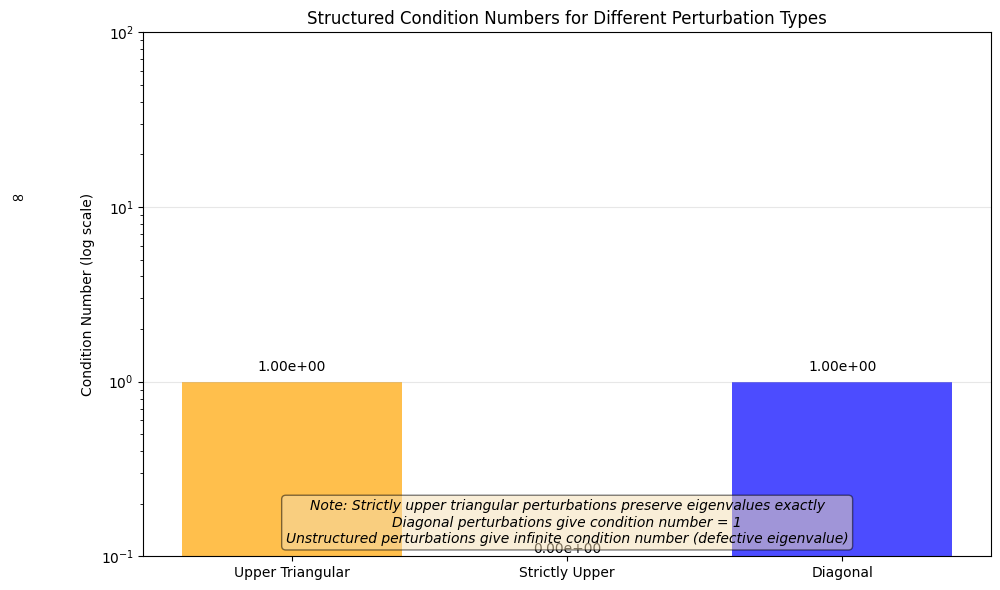

In [5]:
import matplotlib.pyplot as plt

# Compare different perturbation structures
structures = ['Unstructured', 'Upper Triangular', 'Strictly Upper', 'Diagonal']
condition_numbers = [np.inf, kappa_max, 0, 1]  # Theoretical values
colors = ['red', 'orange', 'green', 'blue']

plt.figure(figsize=(10, 6))
bars = plt.bar(structures, condition_numbers, color=colors, alpha=0.7)

# Add text labels
for bar, val in zip(bars, condition_numbers):
    height = bar.get_height()
    if np.isfinite(val):
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
                 f'{val:.2e}', ha='center', va='bottom')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, 10,
                 '∞', ha='center', va='bottom', fontsize=12)

plt.yscale('log')
plt.ylim([0.1, 100])
plt.ylabel('Condition Number (log scale)')
plt.title('Structured Condition Numbers for Different Perturbation Types')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Add explanation
plt.text(0.5, 0.02,
         'Note: Strictly upper triangular perturbations preserve eigenvalues exactly\n'
         'Diagonal perturbations give condition number = 1\n'
         'Unstructured perturbations give infinite condition number (defective eigenvalue)',
         ha='center', va='bottom', transform=plt.gca().transAxes,
         fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

## Power-Law Condition Number for Defective Eigenvalues
When eigenvalues are defective (occur in nontrivial Jordan blocks), the classical condition number is infinite because eigenvalue perturbations scale as $\delta^{1/m}$ rather than $\delta$, where $m$ is the Jordan block size. The power-law condition number captures this fractional scaling behavior.
### Formal Definition
For an eigenvalue $\lambda$ with Jordan block of size $m$, the $m$-th order power-law condition number is:
$$\kappa^{(m)}(\lambda)=\limsup_{\delta\to 0}\frac{|\Delta\lambda|}{\delta^{1/m}}$$
where $\Delta\lambda$ is the eigenvalue shift for perturbations of norm $\delta$.

This measures the constant in front of the fractional power law:
$$|\Delta\lambda|\sim\kappa^{(m)}(\lambda)\delta^{1/m}$$


### Visualization of Power-Law Scaling

<>:50: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:52: SyntaxWarning: invalid escape sequence '\d'
<>:62: SyntaxWarning: invalid escape sequence '\d'
<>:50: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:52: SyntaxWarning: invalid escape sequence '\d'
<>:62: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-407932239.py:50: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_xlabel('Perturbation size $\delta$', fontsize=12)
/tmp/ipython-input-407932239.py:51: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('Maximum eigenvalue shift $|\Delta\lambda|$', fontsize=12)
/tmp/ipython-input-407932239.py:52: SyntaxWarning: invalid escape sequence '\d'
  ax1.set_title('Power-Law Scaling: $\delta^{1/2}$', fontweight='bold')
/tmp/ipython-input-407932239.py:62: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_xlabel('Perturbation size $\delta$', fontsize=12)


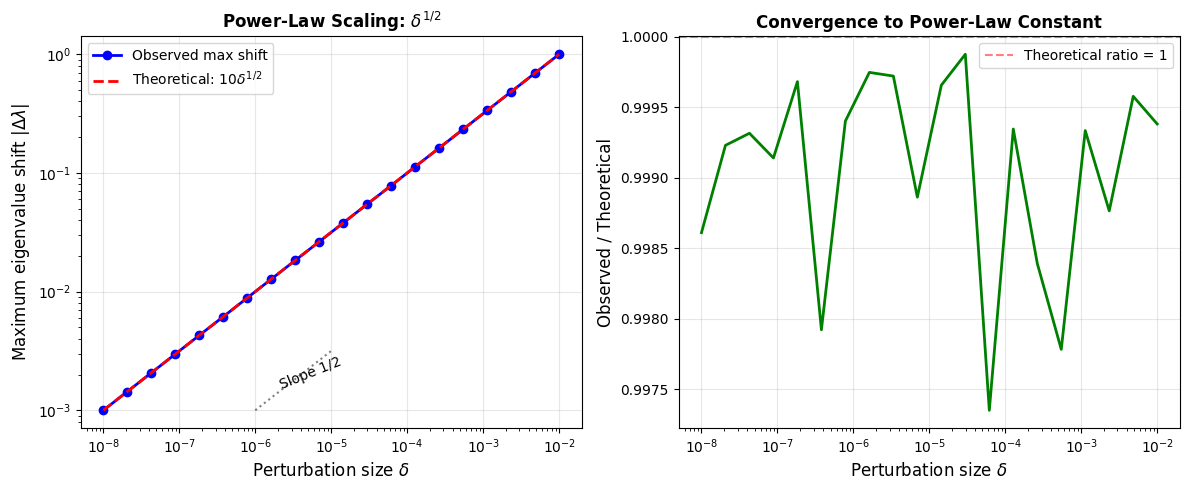

POWER-LAW CONDITION NUMBER ANALYSIS

Eigenvalue: λ = -1
Jordan block size: m = 2

Power-law condition number: κ⁽²⁾(λ) = 10

Interpretation:
For perturbations of size δ, the eigenvalue shifts as:
  |Δλ| ≈ 10·δ^{1/2} = 10√δ

This means:
• δ = 1e-4  →  |Δλ| ≈ 0.1
• δ = 1e-6  →  |Δλ| ≈ 0.001
• δ = 1e-8  →  |Δλ| ≈ 1e-4


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvals

# Define the matrix
A = np.array([[-1, 100], [0, -1]])

# Perturbation sizes
delta_vals = np.logspace(-8, -2, 20)
m = 2  # Jordan block size

# Store maximum eigenvalue shifts
max_shifts = []
theoretical_shifts = []

np.random.seed(42)
num_trials = 1000

for delta in delta_vals:
    shifts = []
    for _ in range(num_trials):
        # Random perturbation with norm delta
        E = np.random.randn(2, 2)
        E = delta * E / np.linalg.norm(E, 2)

        # Compute eigenvalues
        eigvals_perturbed = eigvals(A + E)
        shift = np.max(np.abs(eigvals_perturbed + 1))
        shifts.append(shift)

    max_shifts.append(np.max(shifts))
    theoretical_shifts.append(10 * delta**(1/m))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Log-log plot showing scaling
ax1 = axes[0]
ax1.loglog(delta_vals, max_shifts, 'bo-', linewidth=2, markersize=6,
           label='Observed max shift')
ax1.loglog(delta_vals, theoretical_shifts, 'r--', linewidth=2,
           label=r'Theoretical: $10\delta^{1/2}$')

# Add slope guides
x_ref = 1e-6
y_ref = 1e-3
ax1.loglog([x_ref, 10*x_ref], [y_ref, np.sqrt(10)*y_ref], 'k:', alpha=0.5)
ax1.text(2e-6, 1.5e-3, 'Slope 1/2', rotation=22)

ax1.set_xlabel('Perturbation size $\delta$', fontsize=12)
ax1.set_ylabel('Maximum eigenvalue shift $|\Delta\lambda|$', fontsize=12)
ax1.set_title('Power-Law Scaling: $\delta^{1/2}$', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Ratio to theoretical
ax2 = axes[1]
ratios = np.array(max_shifts) / np.array(theoretical_shifts)
ax2.semilogx(delta_vals, ratios, 'g-', linewidth=2)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Theoretical ratio = 1')

ax2.set_xlabel('Perturbation size $\delta$', fontsize=12)
ax2.set_ylabel('Observed / Theoretical', fontsize=12)
ax2.set_title('Convergence to Power-Law Constant', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print power-law condition number
print("="*60)
print("POWER-LAW CONDITION NUMBER ANALYSIS")
print("="*60)
print(f"\nEigenvalue: λ = -1")
print(f"Jordan block size: m = {m}")
print(f"\nPower-law condition number: κ⁽²⁾(λ) = {10}")
print("\nInterpretation:")
print("For perturbations of size δ, the eigenvalue shifts as:")
print(f"  |Δλ| ≈ {10}·δ^{{1/{m}}} = {10}√δ")
print("\nThis means:")
print("• δ = 1e-4  →  |Δλ| ≈ 0.1")
print("• δ = 1e-6  →  |Δλ| ≈ 0.001")
print("• δ = 1e-8  →  |Δλ| ≈ 1e-4")
print("="*60)

### Numerical Estimation

In [10]:
def estimate_power_law_condition(A, eigenvalue, m, delta_min=1e-8, delta_max=1e-4):
    """Estimate power-law condition number numerically"""
    n = A.shape[0]
    I = np.eye(n)

    # Find approximate eigenvector
    _, v = np.linalg.eig(A)
    v0 = v[:, np.argmin(np.abs(np.diag(A) - eigenvalue))]
    v0 = v0 / np.linalg.norm(v0)

    shifts = []
    deltas = np.logspace(np.log10(delta_min), np.log10(delta_max), 10)

    for delta in deltas:
        # Worst-case perturbation direction
        # For demonstration, use perturbation that maximizes shift
        E = np.zeros_like(A)
        E[-1, 0] = delta  # Bottom-left corner perturbation

        eigvals_perturbed = eigvals(A + E)
        shift = np.min(np.abs(eigvals_perturbed - eigenvalue))
        shifts.append(shift)

    # Fit power law: shift = C * delta^(1/m)
    log_deltas = np.log(deltas)
    log_shifts = np.log(shifts)
    slope, intercept = np.polyfit(log_deltas, log_shifts, 1)

    C = np.exp(intercept)
    return C, slope  # slope should be ~1/m
A = np.array([[-1, 100], [0, -1]])
eigenvalue, _ = np.linalg.eig(A)
C, slope = estimate_power_law_condition(A,eigenvalue,2)
print(f"POWER-LAW CONDITION NUMBER: C={C:.2e}, slope={slope:.2e}")

POWER-LAW CONDITION NUMBER: C=nan, slope=nan


/tmp/ipython-input-4181961375.py:26: RuntimeWarning: divide by zero encountered in log
  log_shifts = np.log(shifts)


# Eigenvalues: The Fundamental Building Blocks of Linear Systems
For a square matrix $A\in\mathbb{C}^{n \times n}$, an eigenvalue $\lambda$ and its corresponding eigenvector $v\ne 0$ satisfy:
$$Av=\lambda v$$
This means: When matrix $A$ acts on vector $v$, it only scales $v$ by factor $\lambda$ without changing its direction.

## Geometric Interpretation
### Eigenvectors as Invariant Directions
Eigenvectors define directions that remain unchanged (except for scaling) under the transformation $A$.

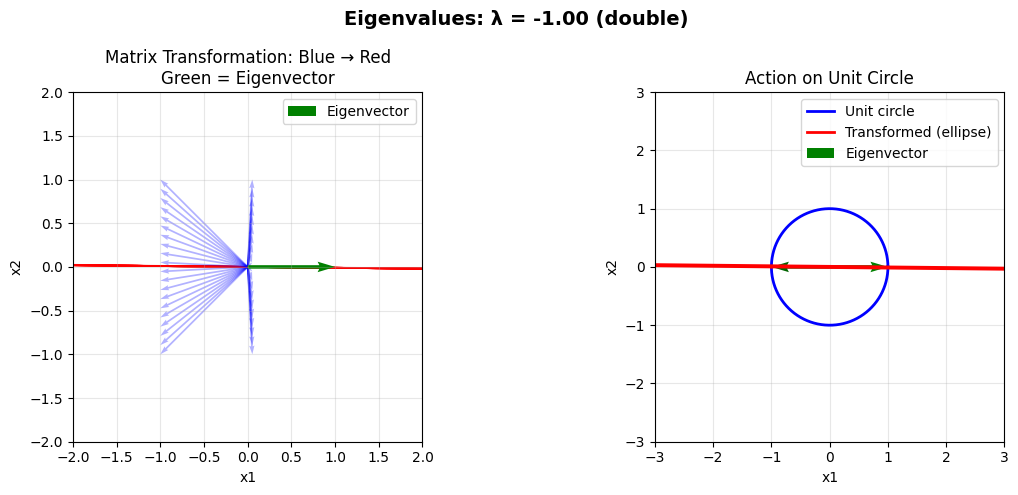

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define our matrix
A = np.array([[-1, 100], [0, -1]])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Original vectors and transformed vectors
x = np.linspace(-1, 1, 20)
y = np.linspace(-1, 1, 20)
X, Y = np.meshgrid(x, y)
vectors = np.stack([X.ravel(), Y.ravel()], axis=1)

# Transform vectors
transformed_vectors = (A @ vectors.T).T

ax1 = axes[0]
for i in range(0, len(vectors), 10):
    v = vectors[i]
    tv = transformed_vectors[i]
    ax1.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color='blue', alpha=0.3, width=0.005)
    ax1.quiver(0, 0, tv[0], tv[1], angles='xy', scale_units='xy', scale=1,
              color='red', alpha=0.5, width=0.005)

# Mark eigenvector direction
eigvec = eigvecs[:, 0]  # Only one eigenvector
ax1.quiver(0, 0, eigvec[0], eigvec[1], angles='xy', scale_units='xy', scale=1,
          color='green', width=0.01, label='Eigenvector')

ax1.set_xlim([-2, 2])
ax1.set_ylim([-2, 2])
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Matrix Transformation: Blue → Red\nGreen = Eigenvector')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Plot 2: Action on unit circle
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])
ellipse = A @ circle

ax2 = axes[1]
ax2.plot(circle[0, :], circle[1, :], 'b-', label='Unit circle', linewidth=2)
ax2.plot(ellipse[0, :], ellipse[1, :], 'r-', label='Transformed (ellipse)', linewidth=2)

# Mark eigenvector on circle
circle_vec = eigvec / np.linalg.norm(eigvec)
ellipse_vec = A @ circle_vec
ax2.quiver(0, 0, circle_vec[0], circle_vec[1], angles='xy', scale_units='xy', scale=1,
          color='green', width=0.01, label='Eigenvector')
ax2.quiver(0, 0, ellipse_vec[0], ellipse_vec[1], angles='xy', scale_units='xy', scale=1,
          color='darkgreen', width=0.01)

ax2.set_xlim([-3, 3])
ax2.set_ylim([-3, 3])
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Action on Unit Circle')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.suptitle(f'Eigenvalues: λ = {eigvals[0]:.2f} (double)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Computation and Properties
- Trace: $tr(A)=\sum \lambda_i$
- Determinant: $\det(A)=\prod \lambda_i$
- similarity transformation: Eigenvalues preserved under $A\to P^{-1}AP$
### Numerical Computation

In [2]:
import numpy as np

# Direct computation for our matrix
A = np.array([[-1, 100], [0, -1]])
eigenvalues = np.linalg.eigvals(A)
print(f"Eigenvalues of A: {eigenvalues}")

# Check properties
trace = np.trace(A)
sum_eig = np.sum(eigenvalues)
print(f"Trace: {trace}, Sum of eigenvalues: {sum_eig}")

determinant = np.linalg.det(A)
product_eig = np.prod(eigenvalues)
print(f"Determinant: {determinant}, Product of eigenvalues: {product_eig}")

# Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"\nEigenvectors (columns):")
print(eigenvectors)

Eigenvalues of A: [-1. -1.]
Trace: -2, Sum of eigenvalues: -2.0
Determinant: 1.0, Product of eigenvalues: 1.0

Eigenvectors (columns):
[[ 1.00000000e+00 -1.00000000e+00]
 [ 0.00000000e+00  2.22044605e-18]]


## Visualizing Eigenvalue Effects

<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2999628216.py:44: SyntaxWarning: invalid escape sequence '\d'
  plt.suptitle('Solutions of $\dot{x} = Ax$ with Different Initial Conditions',


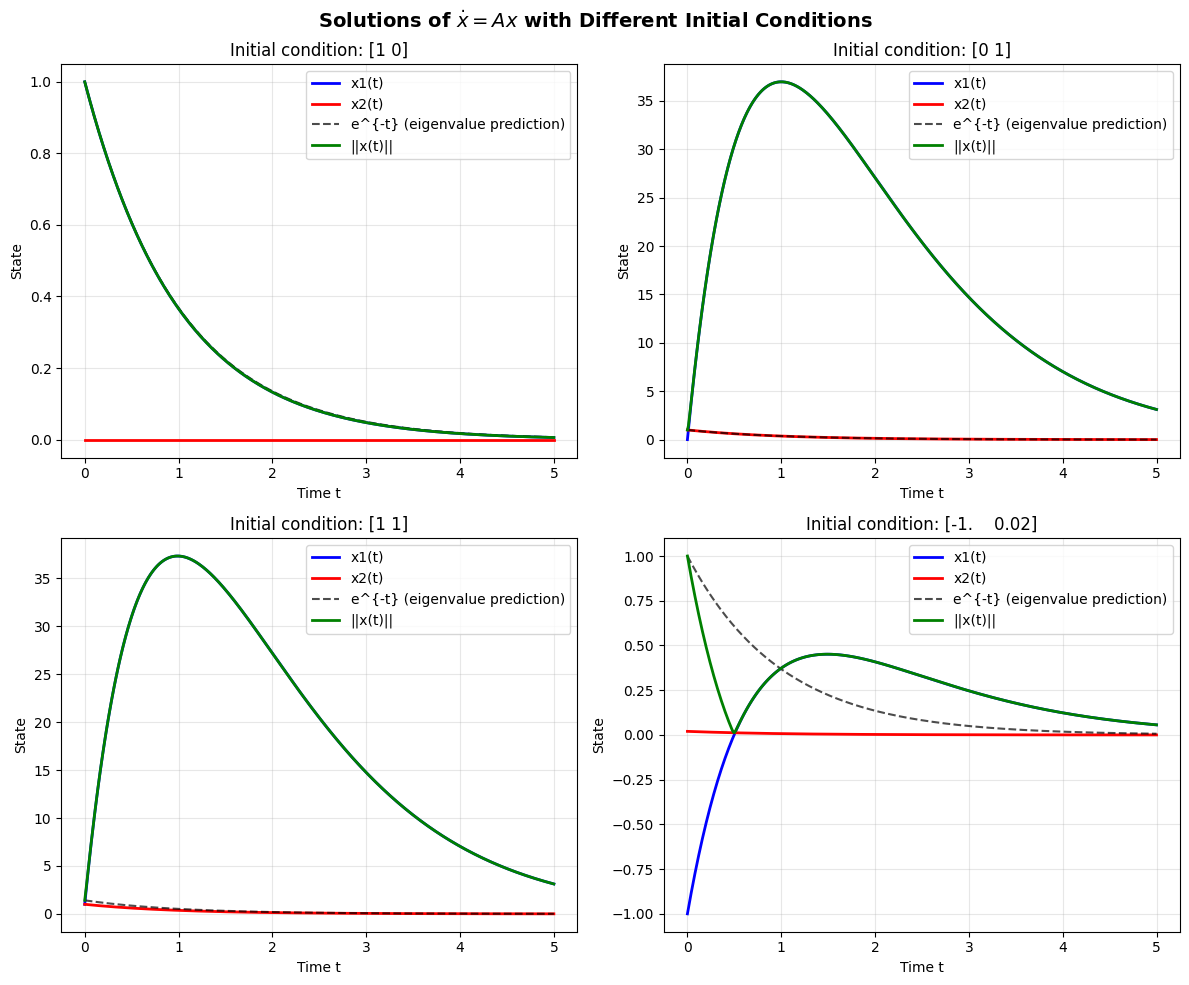

In [3]:
# Evolution of different initial conditions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Time points
t = np.linspace(0, 5, 500)

# Different initial conditions
initial_conditions = [
    np.array([1, 0]),      # Along eigenvector
    np.array([0, 1]),      # Perpendicular
    np.array([1, 1]),      # Mixed
    np.array([-1, 0.02]),  # Near optimal for growth
]

for idx, x0 in enumerate(initial_conditions):
    ax = axes[idx // 2, idx % 2]

    # Compute solution
    x1 = []
    x2 = []
    for ti in t:
        x_t = np.linalg.matrix_power(np.eye(2) + A*ti/100, 100) @ x0  # Approximate e^(At)
        x1.append(x_t[0])
        x2.append(x_t[1])

    # Plot trajectory
    ax.plot(t, x1, 'b-', label='x1(t)', linewidth=2)
    ax.plot(t, x2, 'r-', label='x2(t)', linewidth=2)

    # Plot envelope from eigenvalues
    envelope = np.linalg.norm(x0) * np.exp(-t)
    ax.plot(t, envelope, 'k--', label='e^{-t} (eigenvalue prediction)', alpha=0.7)

    # Plot actual norm
    norm = np.sqrt(np.array(x1)**2 + np.array(x2)**2)
    ax.plot(t, norm, 'g-', label='||x(t)||', linewidth=2)

    ax.set_xlabel('Time t')
    ax.set_ylabel('State')
    ax.set_title(f'Initial condition: {x0}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Solutions of $\dot{x} = Ax$ with Different Initial Conditions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## The Big Picture
Eigenvalues are like the DNA of a matrix – they encode fundamental information about its behavior. However, just as DNA doesn't fully determine an organism's phenotype, eigenvalues don't fully determine a system's transient behavior, especially for non-normal systems.

For complete understanding, we need:
1. Eigenvalues for asymptotic behavior
2. Eigenvectors for mode shapes
3. Pseudospectra for sensitivity and transients
4. Condition numbers for numerical reliability

This comprehensive approach is essential for analyzing real-world systems where non-normality, perturbations, and transient phenomena are common.


# Bauer-Fike Theorem: Eigenvalue Perturbation Bound
## Geometric Interpretation

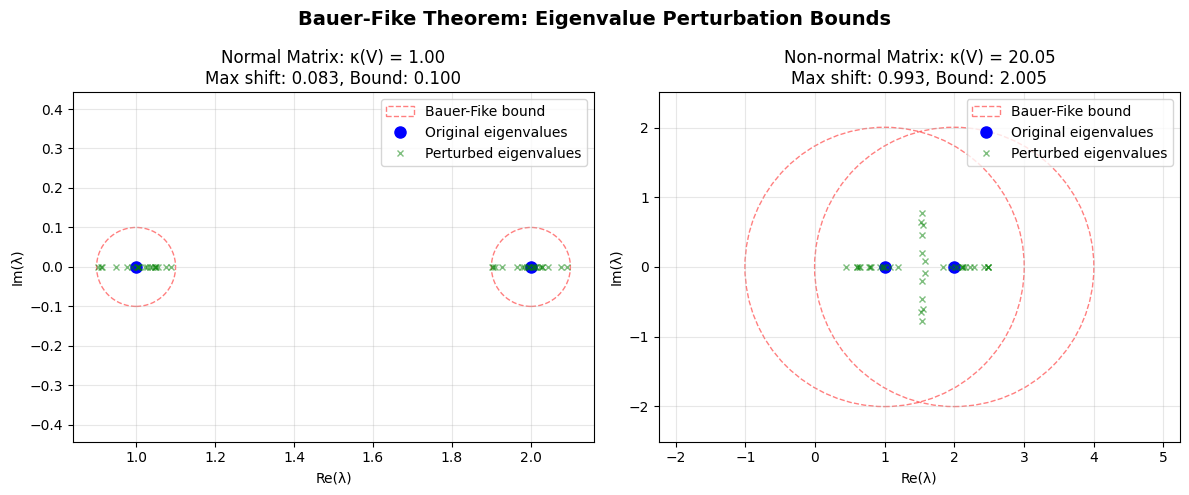

BAUER-FIKE THEOREM DEMONSTRATION

Normal Matrix (symmetric):
  Condition number κ(V) = 1.00
  Bauer-Fike bound: 0.100
  Maximum observed shift: 0.083
  Ratio observed/bound: 0.83

Non-normal Matrix:
  Condition number κ(V) = 20.05
  Bauer-Fike bound: 2.005
  Maximum observed shift: 0.993
  Ratio observed/bound: 0.50



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Example: Compare normal vs non-normal matrices
np.random.seed(42)

# Normal matrix (symmetric)
A_normal = np.array([[1, 0.5], [0.5, 2]])
V_normal, _ = np.linalg.eig(A_normal)
# For symmetric matrices, eigenvectors are orthogonal, V is unitary
V = np.linalg.qr(np.random.randn(2,2))[0]  # Random unitary matrix
Lambda = np.diag([1, 2])
A_normal = V @ Lambda @ V.T  # Construct symmetric matrix

# Non-normal matrix (similar to our example but diagonalizable)
A_nonnormal = np.array([[1, 10], [0, 2]])
# This is triangular, eigenvalues: 1, 2, but eigenvectors are nearly parallel

# Function to compute Bauer-Fike bound
def bauer_fike_bound(A, delta=0.1, num_perturbations=100):
    """Compute eigenvalue perturbations and Bauer-Fike bound"""
    # Diagonalize A
    eigvals, eigvecs = np.linalg.eig(A)
    V = eigvecs
    kappa_V = np.linalg.norm(V, 2) * np.linalg.norm(np.linalg.inv(V), 2)

    # Generate random perturbations
    perturbations = []
    for _ in range(num_perturbations):
        E = np.random.randn(2, 2)
        E = delta * E / np.linalg.norm(E, 2)

        # Eigenvalues of perturbed matrix
        eigvals_pert = np.linalg.eigvals(A + E)

        # Find minimal distance to original eigenvalues
        min_dist = np.min([np.min(np.abs(eigvals_pert - lam)) for lam in eigvals])
        perturbations.append(min_dist)

    return kappa_V, perturbations, max(perturbations)

# Compute bounds
delta = 0.1
kappa_normal, perts_normal, max_shift_normal = bauer_fike_bound(A_normal, delta)
kappa_nonnormal, perts_nonnormal, max_shift_nonnormal = bauer_fike_bound(A_nonnormal, delta)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot for normal matrix
ax1 = axes[0]
eigvals_normal = np.linalg.eigvals(A_normal)
for lam in eigvals_normal:
    # Bauer-Fike bound circle
    circle = Circle((lam.real, lam.imag), kappa_normal*delta,
                   fill=False, color='r', linestyle='--', alpha=0.5,
                   label='Bauer-Fike bound' if lam == eigvals_normal[0] else "")
    ax1.add_patch(circle)

    # Actual eigenvalue location
    ax1.plot(lam.real, lam.imag, 'bo', markersize=8, label='Original eigenvalues' if lam == eigvals_normal[0] else "")

# Plot perturbed eigenvalues (sample)
for i in range(min(20, len(perts_normal))):
    E = np.random.randn(2, 2)
    E = delta * E / np.linalg.norm(E, 2)
    eigvals_pert = np.linalg.eigvals(A_normal + E)
    ax1.plot(eigvals_pert.real, eigvals_pert.imag, 'gx', alpha=0.5, markersize=4,
            label='Perturbed eigenvalues' if i == 0 else "")

ax1.set_xlabel('Re(λ)')
ax1.set_ylabel('Im(λ)')
ax1.set_title(f'Normal Matrix: κ(V) = {kappa_normal:.2f}\nMax shift: {max_shift_normal:.3f}, Bound: {kappa_normal*delta:.3f}')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Plot for non-normal matrix
ax2 = axes[1]
eigvals_nonnormal = np.linalg.eigvals(A_nonnormal)
for lam in eigvals_nonnormal:
    # Bauer-Fike bound circle
    circle = Circle((lam.real, lam.imag), kappa_nonnormal*delta,
                   fill=False, color='r', linestyle='--', alpha=0.5,
                   label='Bauer-Fike bound' if lam == eigvals_nonnormal[0] else "")
    ax2.add_patch(circle)

    # Actual eigenvalue location
    ax2.plot(lam.real, lam.imag, 'bo', markersize=8, label='Original eigenvalues' if lam == eigvals_nonnormal[0] else "")

# Plot perturbed eigenvalues (sample)
for i in range(min(20, len(perts_nonnormal))):
    E = np.random.randn(2, 2)
    E = delta * E / np.linalg.norm(E, 2)
    eigvals_pert = np.linalg.eigvals(A_nonnormal + E)
    ax2.plot(eigvals_pert.real, eigvals_pert.imag, 'gx', alpha=0.5, markersize=4,
            label='Perturbed eigenvalues' if i == 0 else "")

ax2.set_xlabel('Re(λ)')
ax2.set_ylabel('Im(λ)')
ax2.set_title(f'Non-normal Matrix: κ(V) = {kappa_nonnormal:.2f}\nMax shift: {max_shift_nonnormal:.3f}, Bound: {kappa_nonnormal*delta:.3f}')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.suptitle('Bauer-Fike Theorem: Eigenvalue Perturbation Bounds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*60)
print("BAUER-FIKE THEOREM DEMONSTRATION")
print("="*60)
print(f"\nNormal Matrix (symmetric):")
print(f"  Condition number κ(V) = {kappa_normal:.2f}")
print(f"  Bauer-Fike bound: {kappa_normal*delta:.3f}")
print(f"  Maximum observed shift: {max_shift_normal:.3f}")
print(f"  Ratio observed/bound: {max_shift_normal/(kappa_normal*delta):.2f}")

print(f"\nNon-normal Matrix:")
print(f"  Condition number κ(V) = {kappa_nonnormal:.2f}")
print(f"  Bauer-Fike bound: {kappa_nonnormal*delta:.3f}")
print(f"  Maximum observed shift: {max_shift_nonnormal:.3f}")
print(f"  Ratio observed/bound: {max_shift_nonnormal/(kappa_nonnormal*delta):.2f}")

print("\n" + "="*60)

### Approximate Diagonalization
We could slightly perturb $A$ to make it diagonalizable:

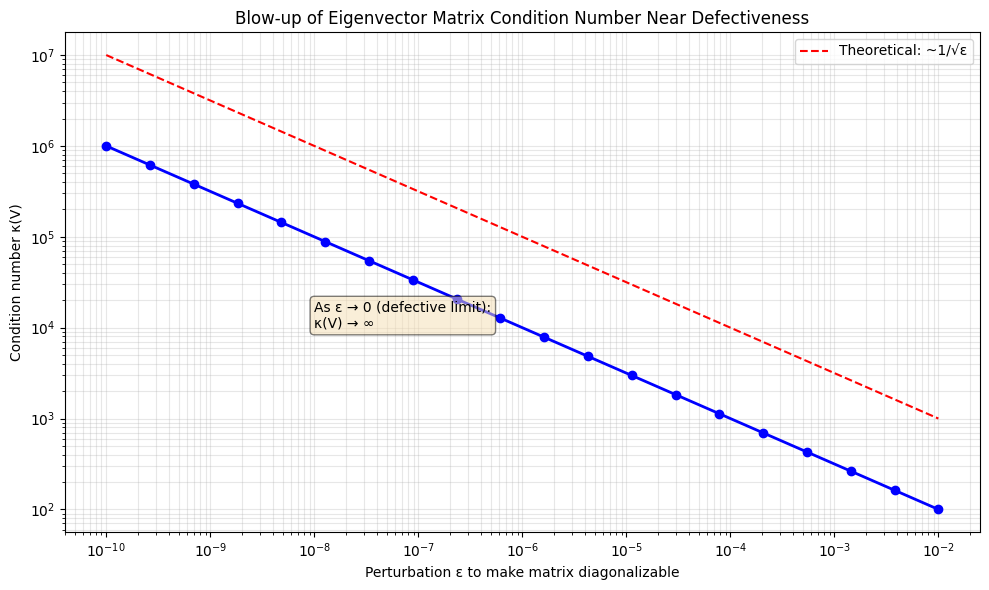

In [5]:
# Show how condition number blows up near defectiveness
epsilons = np.logspace(-10, -2, 20)
kappas = []

for eps in epsilons:
    # Make A diagonalizable by perturbing the (2,1) entry
    A_eps = np.array([[-1, 100], [eps, -1]], dtype=complex)
    eigvals, eigvecs = np.linalg.eig(A_eps)
    V = eigvecs
    kappa = np.linalg.norm(V, 2) * np.linalg.norm(np.linalg.inv(V), 2)
    kappas.append(kappa)

plt.figure(figsize=(10, 6))
plt.loglog(epsilons, kappas, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Perturbation ε to make matrix diagonalizable')
plt.ylabel('Condition number κ(V)')
plt.title('Blow-up of Eigenvector Matrix Condition Number Near Defectiveness')
plt.grid(True, alpha=0.3, which='both')

# Add theoretical scaling
plt.loglog(epsilons, 100/epsilons**0.5, 'r--', label='Theoretical: ~1/√ε')
plt.legend()

plt.text(1e-8, 1e4, 'As ε → 0 (defective limit):\nκ(V) → ∞',
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

As $\varepsilon\to 0$, $\kappa(V)\to\infty$, so the Bauer-Fike bound becomes useless (infinite).

The Bauer-Fike theorem highlights the crucial role of eigenvectors (through $\kappa(V)$) in determining eigenvalue sensitivity, not just the eigenvalues themselves. This is why our matrix, despite having eigenvalues at -1, exhibits high sensitivity and transient growth due to its non-normal (nearly defective) structure.
